# Environment Setup & Library Imports

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set configuration paths for your environment
DATA_PATH = os.path.join("data", "energy_data_set.csv")
OUTPUT_DIR = "reports"

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Setup complete. Output files will save to: ./{OUTPUT_DIR}/")

Setup complete. Output files will save to: ./reports/


# Data Loading & Initial Inspection

In [13]:
print("Loading Dataset")
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at '{DATA_PATH}'. Please verify your data directory.")

# Read dataset and extract chronological variables
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour

print(f"Dataset Shape: {df.shape}")
print(f"Columns Detected: {list(df.columns)}")
df.head()

Loading Dataset
Dataset Shape: (19735, 30)
Columns Detected: ['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17


# Target Variable Skewness & Outliers (Boxplot)

Generating Target Distribution


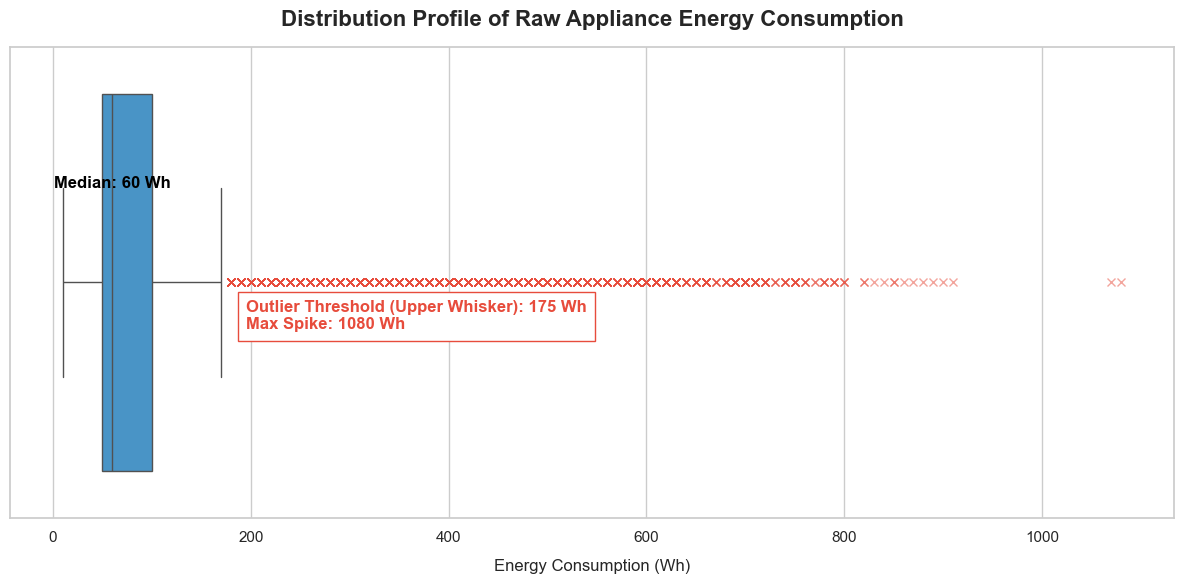

In [14]:
print("Generating Target Distribution")
plt.figure(figsize = (12, 6))
sns.set_theme(style = "whitegrid")

# Create boxplot matching project specifications
ax = sns.boxplot(x = df["Appliances"], color = "#3498db", flierprops = {"marker": "x", "markeredgecolor": "#e74c3c", "alpha": 0.5})

# Calculate statistical markers
median_val = df["Appliances"].median()
q1 = df["Appliances"].quantile(0.25)
q3 = df["Appliances"].quantile(0.75)
iqr = q3 - q1
upper_whisker = q3 + (1.5 * iqr)
max_spike = df["Appliances"].max()

# Render descriptive annotations
plt.text(median_val, -0.2, f"Median: {median_val:.0f} Wh", color = "black", fontweight = "bold", ha = "center")
plt.title("Distribution Profile of Raw Appliance Energy Consumption", fontsize = 16, fontweight = "bold", pad = 15)
plt.xlabel("Energy Consumption (Wh)", fontsize = 12, labelpad = 10)

props = dict(boxstyle = "square,pad = 0.5", facecolor = "white", edgecolor = "#e74c3c")
ax.text(upper_whisker + 20, 0.1, f"Outlier Threshold (Upper Whisker): {upper_whisker:.0f} Wh\nMax Spike: {max_spike:.0f} Wh", color  ="#e74c3c", fontweight = "bold", bbox = props)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "outlier_boxplot.png"), dpi = 300, bbox_inches = "tight")
plt.show()  # Renders the chart beautifully inline in your notebook

# Diurnal Human Behavior Profiles (Hourly Line Trend)

Generating Diurnal Hourly Consumption


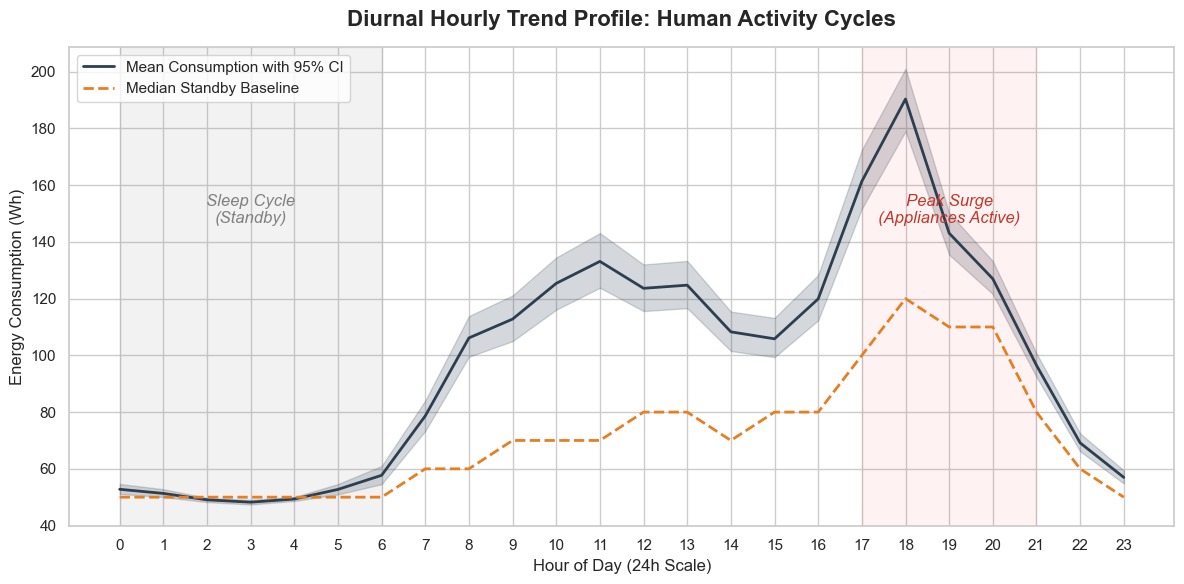

In [15]:
print("Generating Diurnal Hourly Consumption")
plt.figure(figsize = (12, 6))

# Calculate hourly statistics
hourly_stats = df.groupby("hour")["Appliances"].agg(["mean", "median"]).reset_index()

# Render line curves
sns.lineplot(data = df, x = "hour", y = "Appliances", color = "#2c3e50", label = "Mean Consumption with 95% CI", linewidth = 2)
plt.plot(hourly_stats["hour"], hourly_stats["median"], color = "#e67e22", linestyle = "--", linewidth = 2, label = "Median Standby Baseline")
plt.title("Diurnal Hourly Trend Profile: Human Activity Cycles", fontsize = 16, fontweight = "bold", pad = 15)
plt.xlabel("Hour of Day (24h Scale)", fontsize = 12)
plt.ylabel("Energy Consumption (Wh)", fontsize = 12)
plt.xticks(range(0, 24))
plt.legend(loc = "upper left", frameon = True)

# Generate custom block indicators for human routines
plt.axvspan(0, 6, color = "gray", alpha = 0.1)
plt.text(3, df["Appliances"].mean() * 1.5, "Sleep Cycle\n(Standby)", color = "gray", ha = "center", style = "italic")

plt.axvspan(17, 21, color = "red", alpha = 0.05)
plt.text(19, df["Appliances"].mean() * 1.5, "Peak Surge\n(Appliances Active)", color = "#c0392b", ha = "center", style = "italic")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "diurnal_hourly_trends.png"), dpi = 300, bbox_inches = "tight")
plt.show()

# Multivariate Thermodynamic Cross-Correlation (Heatmap)

Compiling Environmental Feature Cross Correlation Matrix


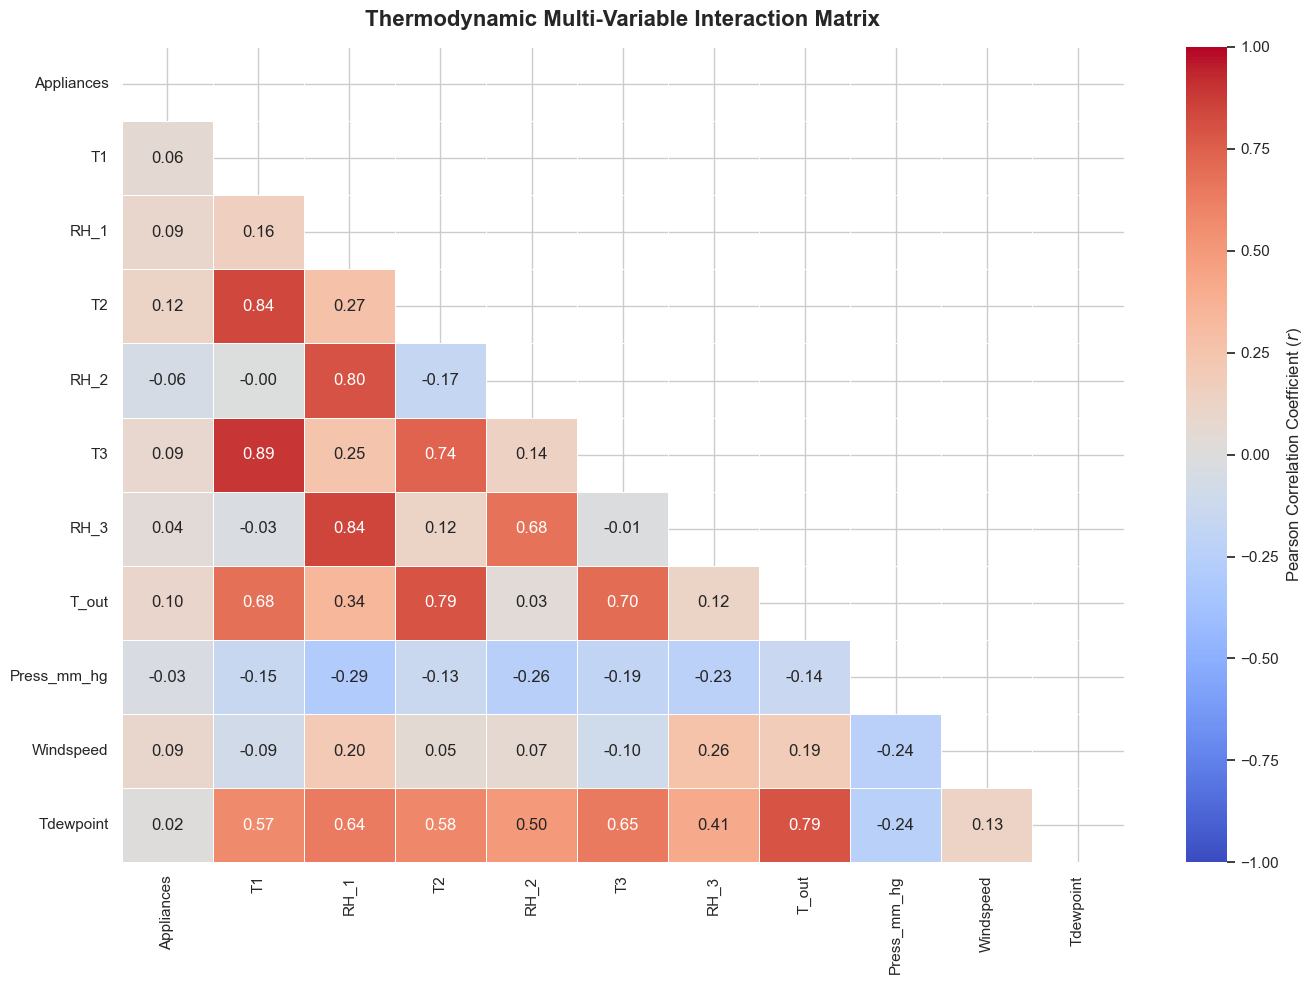

In [16]:
print("Compiling Environmental Feature Cross Correlation Matrix")
plt.figure(figsize = (14, 10))

target_features = [
    "Appliances",
    "T1", "RH_1",  # Kitchen
    "T2", "RH_2",  # Living Room
    "T3", "RH_3",  # Laundry
    "T_out",
    "Press_mm_hg",
    "Windspeed",
    "Tdewpoint"
]

# Extract variables that are present in your specific dataset log
available_features = [col for col in target_features if col in df.columns]
corr_matrix = df[available_features].corr()

# Mask the upper triangle for a clean look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Render heatmap
sns.heatmap(
    corr_matrix,
    mask = mask,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    vmin = -1,
    vmax = 1,
    linewidths = 0.5,
    cbar_kws = {"label": "Pearson Correlation Coefficient ($r$)"}
)
plt.title("Thermodynamic Multi-Variable Interaction Matrix", fontsize = 16, fontweight = "bold", pad = 15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_correlation_heatmap.png"), dpi = 300, bbox_inches = "tight")
plt.show()

# Microclimate Ambient Envelope Tracking (Thermal Lag Lines)

Microclimate Ambient Envelope Tracking


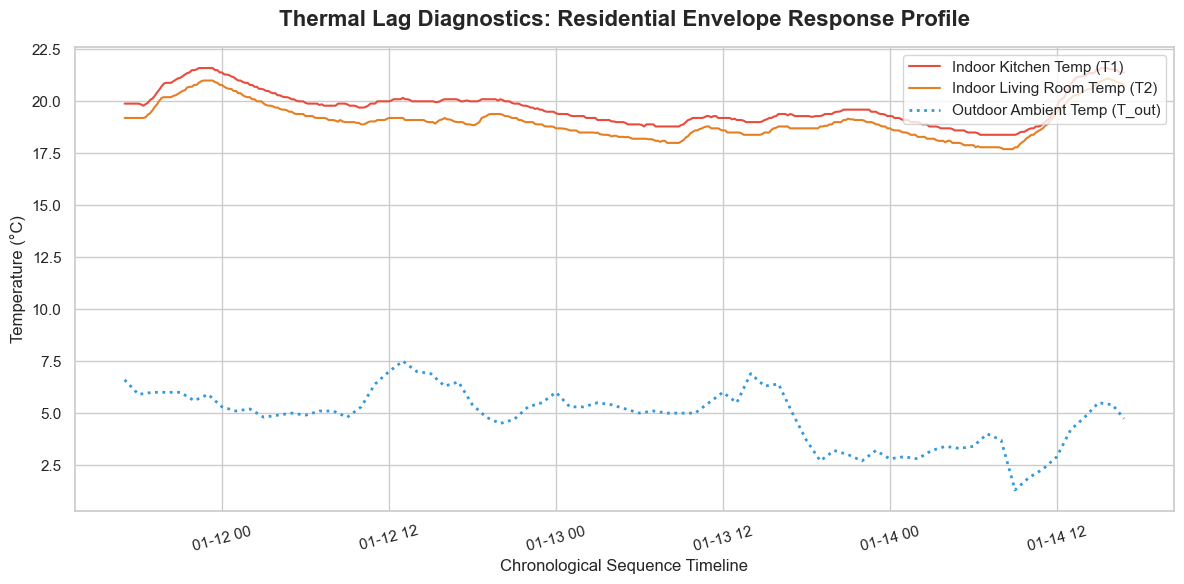


All EDA visualizations generated



In [17]:
print("Microclimate Ambient Envelope Tracking")
plt.figure(figsize = (12, 6))

# Sample a clean 3 day subset (432 intervals * 10 min = 72 hours)
sample_sub = df.head(432)

# Render tracking paths
plt.plot(sample_sub["date"], sample_sub["T1"], color = "#e74c3c", label = "Indoor Kitchen Temp (T1)", linewidth = 1.5)
plt.plot(sample_sub["date"], sample_sub["T2"], color = "#e67e22", label = "Indoor Living Room Temp (T2)", linewidth = 1.5)
plt.plot(sample_sub["date"], sample_sub["T_out"], color = "#3498db", label = "Outdoor Ambient Temp (T_out)", linewidth = 2, linestyle = ":")
plt.title("Thermal Lag Diagnostics: Residential Envelope Response Profile", fontsize = 16, fontweight = "bold", pad = 15)
plt.xlabel("Chronological Sequence Timeline", fontsize = 12)
plt.ylabel("Temperature (°C)", fontsize = 12)
plt.legend(loc = "upper right", frameon = True)
plt.xticks(rotation = 15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "thermal_envelope_tracking.png"), dpi = 300, bbox_inches = "tight")
plt.show()

print("\nAll EDA visualizations generated\n")